In [11]:
# Standard library
import random
import matplotlib.pyplot as plt

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns

# Machine learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.model_selection import KFold

import math

# Custom utilities
from sklearn.preprocessing import StandardScaler

import utils.cross_validation as cval

from math import radians, sin, cos, sqrt, asin


# Essential Params and Dicts

color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}
biome_colors = {
    'Temperate broadleaf forests': "#4881BE",   # Sea Green (mid-tone green)
    'Temperate conifer forests':   "#016742",   # Very Dark Green (near-black green)
    'Temperate grasslands':        '#DAA520',   # Goldenrod (yellow-brown)
    'Xeric shrublands':             '#B5651D',   # Burnt Orange-Brown (desert)
    'Boreal and Tundra forests':    '#4169E1',   # Royal Blue (cool, distinct from green)
    'Mediterranean woodlands':      '#9ACD32',   # Yellow-Green (olive, warm-leaning)
    'Tropical':                     '#FF00FF',   # Magenta (maximally distinct, non-natural but unmistakable)
    'NaN':                          '#D3D3D3'    # Light Gray
}



biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
            "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
            "Mediterranean woodlands"]


In [12]:


def select_one_point_remove_buffer(df,
                                    buffer_km=50,
                                    lat_col='lat', lon_col='lon',
                                    random_seed=None):
    """
    Select exactly ONE point and remove ALL other points within buffer_km.

    Parameters:
    - df: DataFrame with coordinates
    - buffer_km: radius in km to remove points (default: 50)
    - lat_col: latitude column name
    - lon_col: longitude column name
    - random_seed: random seed for reproducibility

    Returns:
    - selected_df: DataFrame with 1 selected point
    - remaining_df: DataFrame with points > buffer_km away (kept)
    - removed_df: DataFrame with points <= buffer_km away (removed)
    """

    if random_seed is not None:
        np.random.seed(random_seed)

    selected_idx = np.random.choice(df.index, 1, replace=False)[0]

    # Get selected point coordinates
    selected_point = df.loc[selected_idx]
    lat_sel = selected_point[lat_col]
    lon_sel = selected_point[lon_col]

    # Classify all points
    selected_points = [selected_idx]
    removed_points = []
    remaining_points = []

    for idx in df.index:
        if idx == selected_idx:
            continue

        # Calculate distance to selected point
        dist = haversine(lat_sel, lon_sel,
                          df.loc[idx, lat_col],
                          df.loc[idx, lon_col])

        if dist <= buffer_km:
            removed_points.append(idx)  # Too close → remove
        else:
            remaining_points.append(idx)  # Far enough → keep

    # Create DataFrames
    selected_df = df.loc[selected_points].copy()
    removed_df = df.loc[removed_points].copy()
    remaining_df = df.loc[remaining_points].copy()

    print(f"✓ Removed {len(removed_df)} points within {buffer_km}km")

    return selected_df, remaining_df, removed_df


def train_test_split_v3(df, random_key, n_points_to_select=2, buffer_km=100):

    selected, remaining, removed = select_one_point_remove_buffer(
        df,
        buffer_km=50,
        lat_col='lat', lon_col='lon',
        random_seed=random_key
    )

    test = selected.drop(columns=['lat', 'lon', 'biome', 'treecover2000'])
    test_biomes = selected[['biome']]
    train = remaining.drop(columns=['lat', 'lon', 'biome', 'treecover2000'])

    # --- Target changed to Species Richness ---
    y = ['Species Richness']
    X_train = train.drop(columns=y + ['PID'])
    y_train = train['Species Richness'].values

    X_test = test.drop(columns=y + ['PID'])
    y_test = test['Species Richness'].values

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test, test_biomes, scaler


def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))

    return R * c



In [16]:

biome_mapping = {
    'Temperate broadleaf forests': 'Temperate broadleaf forests',
    'Temperate conifer forests': 'Temperate conifer forests',
    'Temperate grasslands': 'Temperate grasslands',
    'Xeric shrublands': 'Xeric shrublands',
    'Mediterranean woodlands': 'Mediterranean woodlands',
    'Flooded grasslands': 'Flooded grasslands',
    'Mangroves': 'Mangroves',
    'Tundra': 'Boreal and Tundra forests',
    'Boreal forests or taiga': 'Boreal and Tundra forests',
    'Tropical grasslands': 'Tropical',
    'Tropical coniferous forests': 'Tropical',
    'Tropical moist broadleaf forests': 'Tropical',
    'Tropical dry broadleaf forests': 'Tropical',
    np.nan: np.nan,  # Will be dropped
}

biome_list = ["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
                "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
                "Mediterranean woodlands"]

fd_df = pd.read_csv('data/final/final_dataset.csv')
PID_df = pd.read_csv('data/lookup/PID_location_all.csv')

fd_df = fd_df.merge(PID_df[['PID', 'lat', 'lon', 'biome']], on='PID', how='left')

npp_df = pd.read_csv('data/processed/PID_npp_volatility.csv')
npp_df = npp_df[['PID', 'mean']]

fd_df = fd_df.merge(npp_df, on='PID', how='left')
fd_df = fd_df[~fd_df["biome"].isin(["Mangroves", "Flooded grasslands"])]
fd_df.drop_duplicates(subset=['PID'], inplace=True)

fd_df.dropna(subset=['transformed npp', 'Raos_Q', 'Functional_Evenness', 'Soil Moisture',
                        'Species Richness', 'Shannon Diversity', "Simpson's Index", 'biome', "pet_std"],
                inplace=True)

# fd_df.drop(columns=['Functional_Richness', 'Raos_Q', 'Functional_Evenness', 'Shannon Diversity', "Simpson's Index", 'WSCI', 'transformed npp'], inplace=True)

fd_df = fd_df[fd_df["treecover2000"] > 30]
fd_df = fd_df[fd_df["WSCI"] != 0]

ecoregions = cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")
ecoregions = ecoregions[['ECO_NAME', 'geometry']]

fd_df['biome'] = fd_df['biome'].map(biome_mapping)  # Only run this once!

biome_dfs = {k: v for k, v in fd_df.groupby('biome')}

random_keys = random.sample(range(1, 100000), 200)  # Generate n random keys for reproducibility


Regression: WSCI = 0.4882 * mean + 9.4566
R-squared: 0.0562
p-value: 0
Standard error of slope: 0.0088


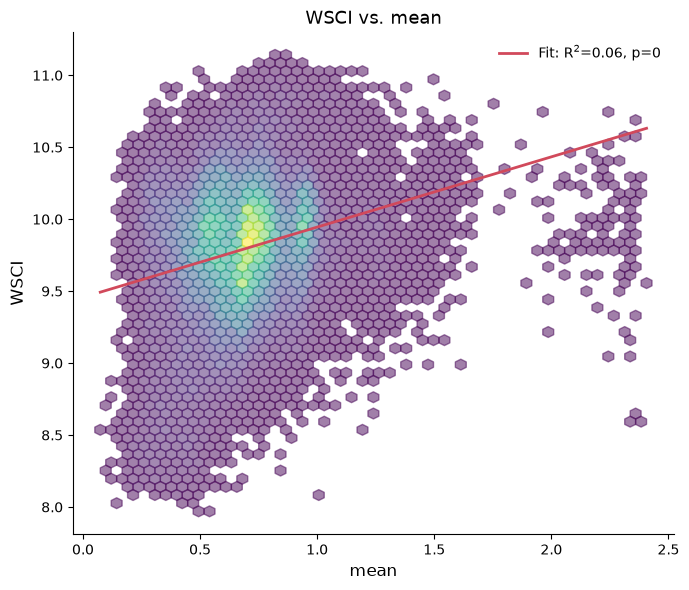

In [17]:

# ---- 2. Define columns ----
from scipy import stats


x_col = "mean"  # predictor
y_col = "WSCI"             # response

# Drop rows with missing values in either column
data = fd_df[[x_col, y_col]].dropna()
x = data[x_col].values
y = data[y_col].values

# ---- 3. Fit linear regression ----
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2

print(f"Regression: {y_col} = {slope:.4f} * {x_col} + {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"p-value: {p_value:.4g}")
print(f"Standard error of slope: {std_err:.4f}")

# ---- 4. Plot ----
fig, ax = plt.subplots(figsize=(7, 6))

# Scatter points
hb = ax.hexbin(x, y, gridsize=50, alpha=0.5, cmap='viridis', mincnt=1)
# Regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#d1495b", linewidth=2,
         label=f"Fit: R$^2$={r_squared:.2f}, p={p_value:.2g}")

ax.set_xlabel(x_col, fontsize=12)
ax.set_ylabel(y_col, fontsize=12)
ax.set_title(f"{y_col} vs. {x_col}", fontsize=13)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

✓ Removed 114 points within 50km
completed iteration 1
✓ Removed 64 points within 50km
completed iteration 2
✓ Removed 79 points within 50km
completed iteration 3
✓ Removed 252 points within 50km
completed iteration 4
✓ Removed 132 points within 50km
completed iteration 5
✓ Removed 93 points within 50km
completed iteration 6
✓ Removed 228 points within 50km
completed iteration 7
✓ Removed 102 points within 50km
completed iteration 8
✓ Removed 169 points within 50km
completed iteration 9
✓ Removed 325 points within 50km
completed iteration 10
✓ Removed 520 points within 50km
completed iteration 11
✓ Removed 110 points within 50km
completed iteration 12
✓ Removed 78 points within 50km
completed iteration 13
✓ Removed 291 points within 50km
completed iteration 14
✓ Removed 109 points within 50km
completed iteration 15
✓ Removed 23 points within 50km
completed iteration 16
✓ Removed 169 points within 50km
completed iteration 17
✓ Removed 106 points within 50km
completed iteration 18
✓ Remo

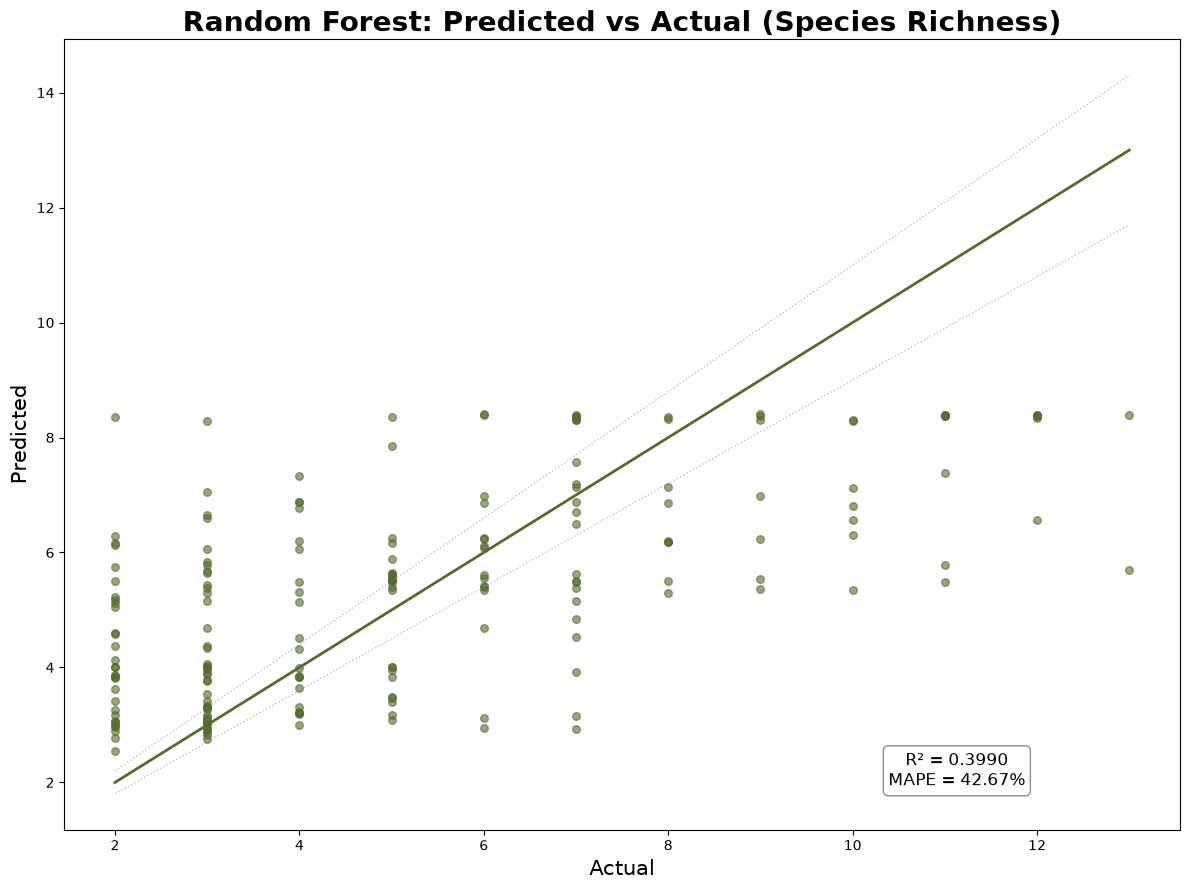

In [15]:

y_pred_all = []
y_actual_all = []
for i in range(len(random_keys)):

    random_key = random_keys[i]
    fX_train, fy_train, fX_test, fy_test, test_biomes, scaler = train_test_split_v3(
        fd_df, random_key=random_key, n_points_to_select=1, buffer_km=50
    )

    # --- Linear Regression model ---
    model =  RandomForestRegressor(max_depth=6, n_jobs =-1, random_state=0)
    model.fit(fX_train, fy_train)

    # Make predictions
    y_pred = model.predict(fX_test)

    y_pred_all.append(y_pred)
    y_actual_all.append(fy_test)

    print(f"completed iteration {i + 1}")

df = pd.DataFrame({
    'y_pred_all': y_pred_all,
    'y_actual_all': y_actual_all,
})

# If each value is a list like [1], [2], [3]
# Extract the first (and only) element from each list
df['y_actual_all'] = df['y_actual_all'].apply(lambda x: x[0])
df['y_pred_all'] = df['y_pred_all'].apply(lambda x: x[0])



# Clean the data before plotting
df_clean = df[['y_actual_all', 'y_pred_all']].copy()

# Force numeric conversion
df_clean['y_actual_all'] = pd.to_numeric(df_clean['y_actual_all'], errors='coerce')
df_clean['y_pred_all'] = pd.to_numeric(df_clean['y_pred_all'], errors='coerce')

figsize = (12, 14)

fig, ax_scatter = plt.subplots(1, 1, figsize=(figsize[0], figsize[1] // 1.5))

hb = ax_scatter.scatter(df_clean['y_actual_all'],
                            df_clean['y_pred_all'],
                            color='darkolivegreen',
                            alpha=0.6,
                            s=30)

# Perfect fit line
min_val = min(df['y_actual_all'].min(), df['y_pred_all'].min())
max_val = max(df['y_actual_all'].max(), df['y_pred_all'].max())
ax_scatter.plot([min_val, max_val], [min_val, max_val], 'darkolivegreen', lw=2, label='Perfect fit')

# Add 10% error bands (optional)
ax_scatter.plot([min_val, max_val], [min_val * 1.1, max_val * 1.1], 'gray', lw=1, alpha=0.5, linestyle=':')
ax_scatter.plot([min_val, max_val], [min_val * 0.9, max_val * 0.9], 'gray', lw=1, alpha=0.5, linestyle=':')

ax_scatter.set_xlabel('Actual', fontsize=15)
ax_scatter.set_ylabel('Predicted', fontsize=15)
title = 'Random Forest: Predicted vs Actual (Species Richness)'
ax_scatter.set_title(title, fontsize=20, fontweight='bold')

r2 = r2_score(df_clean['y_actual_all'], df_clean['y_pred_all'])
mape = mean_absolute_percentage_error(df_clean['y_actual_all'], df_clean['y_pred_all']) * 100

# --- ADD TEXT BOX AT BOTTOM ---
metrics_text = f'R² = {r2:.4f}\nMAPE = {mape:.2f}%'
ax_scatter.text(0.8, 0.1, metrics_text,
                    transform=ax_scatter.transAxes,
                    fontsize=12,
                    verticalalignment='top',
                    horizontalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.savefig('results/random_forest_species_richness_predicted_vs_actual.png', dpi=300)